# 💰 Phase 2 — Damage Cost Estimation Engine

This notebook builds the cost estimation layer that sits on top of your trained YOLO model.

### What this phase produces
| Output | Description |
|---|---|
| `cost_estimator.py` | Rule-based estimator (instant, no ML needed) |
| `train_cost_model.py` | Synthetic data generator + XGBoost regressor |
| `cost_model.pkl` | Trained regression model saved to disk |
| `predict_pipeline.py` | Full chain: image → YOLO → cost → JSON output |

### Two-layer approach
```
Layer 1 (Rule-based)  →  Fast, transparent, always works
Layer 2 (ML model)    →  More accurate, learns from patterns
```
We build Layer 1 first so you have something working immediately, then Layer 2 on top.

---
## ⚙️ Cell 1 — Install Dependencies

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn ultralytics joblib -q
print("✅ All dependencies installed.")

✅ All dependencies installed.


---
## 📦 Cell 2 — Imports & Config

In [2]:
import os
import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# ── Paths ────────────────────────────────────────────────────
MODEL_PATH   = Path("/teamspace/studios/this_studio/CarDD-outputs/runs/yolov8m_novel/weights/best.pt")
OUTPUT_DIR   = Path("/teamspace/studios/this_studio/CarDD-outputs/phase2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Class names (must match your YOLO training order) ────────
CLASS_NAMES = ["dent", "scratch", "crack", "glass shatter", "tire flat", "lamp broken"]
NUM_CLASSES = len(CLASS_NAMES)

print("✅ Imports and config ready.")
print(f"   Output dir : {OUTPUT_DIR}")
print(f"   Model path : {MODEL_PATH}")
print(f"   Classes    : {CLASS_NAMES}")

✅ Imports and config ready.
   Output dir : /teamspace/studios/this_studio/CarDD-outputs/phase2
   Model path : /teamspace/studios/this_studio/CarDD-outputs/runs/yolov8m_novel/weights/best.pt
   Classes    : ['dent', 'scratch', 'crack', 'glass shatter', 'tire flat', 'lamp broken']


---
## 🔧 Cell 3 — Layer 1: Rule-Based Cost Estimator

This is your **immediate working estimator**. No training needed.

Logic:
- Each damage type has a base cost range (INR)
- Bigger bounding box = more expensive (area multiplier)
- Multiple damages = each adds to total
- Severity score from YOLO confidence adjusts final cost

In [3]:
# ─────────────────────────────────────────────────────────────
# RULE-BASED COST ESTIMATOR
# ─────────────────────────────────────────────────────────────

# Base repair cost ranges in INR for each damage type
# (min_cost, max_cost) — research-based realistic estimates
BASE_COST_INR = {
    "dent":          (3000,  10000),
    "scratch":       (1500,   6000),
    "crack":         (5000,  15000),
    "glass shatter": (8000,  25000),
    "tire flat":     (2000,   8000),
    "lamp broken":   (3500,  12000),
}

# Severity tiers based on bounding box area
# (as fraction of total image area)
# Small: <5%, Medium: 5-15%, Large: >15%
SEVERITY_MULTIPLIER = {
    "small":  1.0,
    "medium": 1.5,
    "large":  2.2,
}


def get_severity(bbox_area_fraction: float) -> str:
    """Classify damage severity based on bounding box area."""
    if bbox_area_fraction < 0.05:
        return "small"
    elif bbox_area_fraction < 0.15:
        return "medium"
    else:
        return "large"


def rule_based_estimate(detections: list, img_width: int = 640, img_height: int = 640) -> dict:
    """
    Estimate repair cost from YOLO detections using rules.

    Args:
        detections: List of dicts, each with:
                    {
                        'class':      str,   e.g. 'dent'
                        'confidence': float, e.g. 0.87
                        'bbox':       [x1, y1, x2, y2]  (absolute pixels)
                    }
        img_width:  Width of input image in pixels
        img_height: Height of input image in pixels

    Returns:
        dict with cost breakdown and summary
    """
    if not detections:
        return {
            "total_min": 0,
            "total_max": 0,
            "estimated_cost": 0,
            "breakdown": [],
            "damage_count": 0,
            "severity_summary": "No damage detected",
        }

    img_area = img_width * img_height
    total_min = 0
    total_max = 0
    breakdown = []

    for det in detections:
        cls      = det["class"]
        conf     = det["confidence"]
        x1, y1, x2, y2 = det["bbox"]

        # Calculate bounding box area as fraction of image
        bbox_area   = (x2 - x1) * (y2 - y1)
        area_frac   = bbox_area / img_area
        severity    = get_severity(area_frac)
        multiplier  = SEVERITY_MULTIPLIER[severity]

        # Get base cost for this damage type
        base_min, base_max = BASE_COST_INR.get(cls, (2000, 8000))

        # Apply severity multiplier
        item_min = base_min * multiplier
        item_max = base_max * multiplier

        # Confidence adjustment: low confidence = wider uncertainty
        # High confidence (>0.8) keeps estimate tight
        conf_factor = 0.8 + (conf * 0.2)   # 0.8 to 1.0 range
        item_min *= conf_factor

        total_min += item_min
        total_max += item_max

        breakdown.append({
            "class":       cls,
            "confidence":  round(conf, 3),
            "severity":    severity,
            "area_pct":    round(area_frac * 100, 1),
            "cost_min":    round(item_min),
            "cost_max":    round(item_max),
        })

    # Multiple damage penalty: each extra damage adds 10% to total
    count = len(detections)
    if count > 1:
        penalty = 1 + (count - 1) * 0.10
        total_min *= penalty
        total_max *= penalty

    estimated_cost = round((total_min + total_max) / 2)

    # Overall severity label
    if estimated_cost < 10000:
        severity_summary = "Minor damage"
    elif estimated_cost < 30000:
        severity_summary = "Moderate damage"
    elif estimated_cost < 60000:
        severity_summary = "Severe damage"
    else:
        severity_summary = "Major damage — consider total loss"

    return {
        "total_min":        round(total_min),
        "total_max":        round(total_max),
        "estimated_cost":   estimated_cost,
        "breakdown":        breakdown,
        "damage_count":     count,
        "severity_summary": severity_summary,
    }


print("✅ Rule-based estimator defined.")

✅ Rule-based estimator defined.


---
## 🧪 Cell 4 — Test the Rule-Based Estimator

We pass fake YOLO detection output (same format as the real model) to verify it works.

In [4]:
# Simulate what your YOLO model would output for a damaged car image
fake_detections = [
    {
        "class":      "dent",
        "confidence": 0.91,
        "bbox":       [100, 150, 280, 290],   # x1,y1,x2,y2 in pixels
    },
    {
        "class":      "scratch",
        "confidence": 0.78,
        "bbox":       [300, 200, 500, 240],
    },
    {
        "class":      "glass shatter",
        "confidence": 0.85,
        "bbox":       [420, 80, 580, 180],
    },
]

result = rule_based_estimate(fake_detections, img_width=640, img_height=640)

print("\n" + "="*55)
print("  RULE-BASED ESTIMATE RESULT")
print("="*55)
print(f"  Damage count     : {result['damage_count']}")
print(f"  Severity         : {result['severity_summary']}")
print(f"  Estimated cost   : ₹{result['estimated_cost']:,}")
print(f"  Range            : ₹{result['total_min']:,} — ₹{result['total_max']:,}")
print("\n  Breakdown:")
for item in result["breakdown"]:
    print(f"    {item['class']:<15} | severity: {item['severity']:<6} "
          f"| area: {item['area_pct']}% "
          f"| ₹{item['cost_min']:,} – ₹{item['cost_max']:,}")


  RULE-BASED ESTIMATE RESULT
  Damage count     : 3
  Severity         : Severe damage
  Estimated cost   : ₹35,768
  Range            : ₹16,336 — ₹55,200

  Breakdown:
    dent            | severity: medium | area: 6.2% | ₹4,419 – ₹15,000
    scratch         | severity: small  | area: 2.0% | ₹1,434 – ₹6,000
    glass shatter   | severity: small  | area: 3.9% | ₹7,760 – ₹25,000


---
## 🏭 Cell 5 — Generate Synthetic Training Data for ML Model

CarDD dataset has no real cost labels, so we simulate realistic training data.

**How the simulation works:**
- Generate 5000 random damage scenarios
- Each scenario has 1–5 damage detections with random types, sizes, confidences
- Use the rule-based estimator as a "ground truth" + add realistic noise
- This teaches the ML model patterns the rules encode, but it can generalise further

In [5]:
def generate_synthetic_dataset(n_samples: int = 5000) -> pd.DataFrame:
    """
    Generate realistic synthetic damage scenarios for ML training.

    Each row = one car inspection with:
      - One-hot encoded damage type counts
      - Total bbox area features
      - Severity scores
      - Target: repair cost (INR)
    """
    records = []

    for _ in range(n_samples):
        # Random number of damage regions per image (1 to 5)
        n_damages = random.choices([1, 2, 3, 4, 5], weights=[30, 30, 20, 12, 8])[0]

        detections = []
        for _ in range(n_damages):
            cls  = random.choice(CLASS_NAMES)
            conf = random.uniform(0.5, 0.99)

            # Random bbox — ensure x2>x1, y2>y1
            x1 = random.randint(0,   500)
            y1 = random.randint(0,   500)
            x2 = random.randint(x1 + 20, min(x1 + 300, 640))
            y2 = random.randint(y1 + 20, min(y1 + 300, 640))

            detections.append({
                "class":      cls,
                "confidence": conf,
                "bbox":       [x1, y1, x2, y2],
            })

        # Get rule-based estimate as base cost
        est = rule_based_estimate(detections)
        base_cost = est["estimated_cost"]

        # Add realistic noise (±20%) to simulate real-world variation
        # e.g. labour rates, region, car model, garage markup
        noise_factor = random.uniform(0.80, 1.20)
        actual_cost  = max(500, base_cost * noise_factor)

        # ── Feature engineering ──────────────────────────────
        # Count each damage type
        class_counts = {cls: 0 for cls in CLASS_NAMES}
        for det in detections:
            class_counts[det["class"]] += 1

        # Total and max bbox area fraction
        img_area  = 640 * 640
        areas     = [(d["bbox"][2]-d["bbox"][0])*(d["bbox"][3]-d["bbox"][1]) / img_area
                     for d in detections]
        total_area = sum(areas)
        max_area   = max(areas)
        avg_area   = total_area / len(areas)

        # Average and min confidence
        confs      = [d["confidence"] for d in detections]
        avg_conf   = sum(confs) / len(confs)
        min_conf   = min(confs)

        # Severity scores: small=1, medium=2, large=3
        sev_map = {"small": 1, "medium": 2, "large": 3}
        sev_scores = [sev_map[get_severity(a)] for a in areas]
        max_severity = max(sev_scores)
        avg_severity = sum(sev_scores) / len(sev_scores)

        # Has high-value damage types
        has_glass   = int(class_counts["glass shatter"] > 0)
        has_crack   = int(class_counts["crack"] > 0)
        has_lamp    = int(class_counts["lamp broken"] > 0)

        record = {
            # Damage type counts
            **{f"count_{cls.replace(' ', '_')}": class_counts[cls] for cls in CLASS_NAMES},
            # Area features
            "total_area_frac":  round(total_area, 4),
            "max_area_frac":    round(max_area,   4),
            "avg_area_frac":    round(avg_area,   4),
            # Damage count
            "damage_count":     n_damages,
            # Confidence features
            "avg_confidence":   round(avg_conf,  3),
            "min_confidence":   round(min_conf,  3),
            # Severity
            "max_severity":     max_severity,
            "avg_severity":     round(avg_severity, 2),
            # High-value flags
            "has_glass_shatter": has_glass,
            "has_crack":         has_crack,
            "has_lamp_broken":   has_lamp,
            # Target variable
            "repair_cost_inr":  round(actual_cost),
        }
        records.append(record)

    df = pd.DataFrame(records)
    return df


print("Generating 5000 synthetic damage scenarios...")
df = generate_synthetic_dataset(n_samples=5000)

# Save raw dataset
csv_path = OUTPUT_DIR / "synthetic_damage_dataset.csv"
df.to_csv(csv_path, index=False)

print(f"\n✅ Dataset generated: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Saved → {csv_path}")
print(f"\n   Cost range : ₹{df['repair_cost_inr'].min():,.0f} — ₹{df['repair_cost_inr'].max():,.0f}")
print(f"   Mean cost  : ₹{df['repair_cost_inr'].mean():,.0f}")
print(f"   Std dev    : ₹{df['repair_cost_inr'].std():,.0f}")
df.head()

Generating 5000 synthetic damage scenarios...

✅ Dataset generated: 5000 rows × 18 columns
   Saved → /teamspace/studios/this_studio/CarDD-outputs/phase2/synthetic_damage_dataset.csv

   Cost range : ₹2,956 — ₹141,744
   Mean cost  : ₹29,099
   Std dev    : ₹21,626


,count_dent,count_scratch,count_crack,count_glass_shatter,count_tire_flat,count_lamp_broken,total_area_frac,max_area_frac,avg_area_frac,damage_count,avg_confidence,min_confidence,max_severity,avg_severity,has_glass_shatter,has_crack,has_lamp_broken,repair_cost_inr
0,2,0,0,0,0,1,0.0465,0.0207,0.0155,3,0.757,0.546,1,1.00,0,0,1,26758
1,1,0,0,1,0,1,0.1408,0.0742,0.0469,3,0.620,0.545,2,1.67,1,0,1,50129
2,0,0,0,0,1,2,0.0893,0.0481,0.0298,3,0.633,0.534,1,1.00,0,0,1,27658
3,0,0,1,1,1,1,0.1497,0.0825,0.0374,4,0.751,0.636,2,1.25,1,1,1,47751
4,0,0,1,0,0,0,0.0566,0.0566,0.0566,1,0.697,0.697,2,2.00,0,1,0,15690


---
## 📊 Cell 6 — Explore the Synthetic Dataset

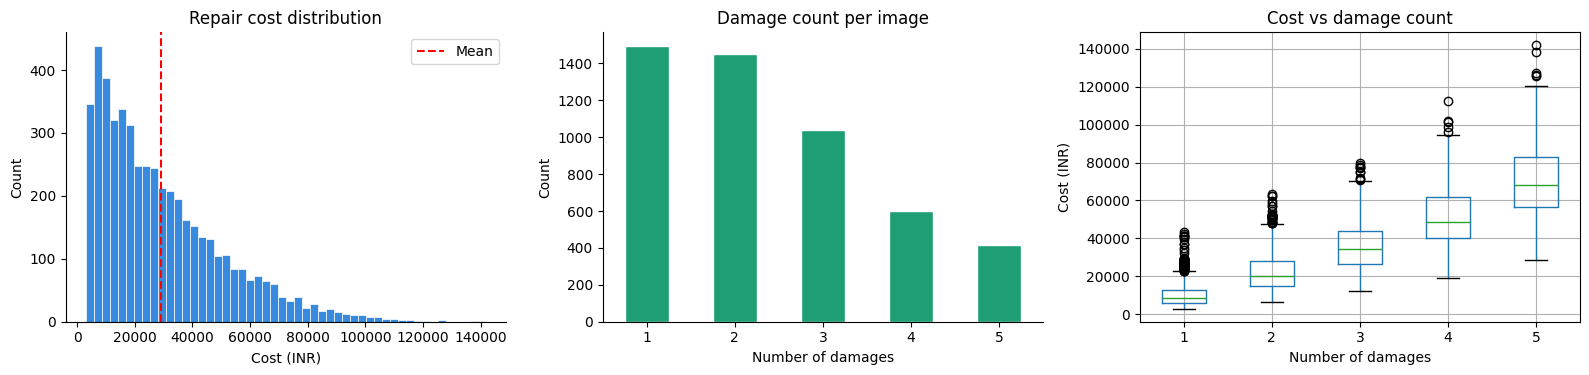

✅ Dataset overview chart saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Synthetic Dataset Overview", fontsize=14, fontweight="bold")

# Cost distribution
ax = axes[0]
ax.hist(df["repair_cost_inr"], bins=50, color="#378ADD", edgecolor="white", linewidth=0.5)
ax.set_title("Repair cost distribution")
ax.set_xlabel("Cost (INR)")
ax.set_ylabel("Count")
ax.axvline(df["repair_cost_inr"].mean(), color="red", linestyle="--", label="Mean")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

# Damage count distribution
ax2 = axes[1]
df["damage_count"].value_counts().sort_index().plot(kind="bar", ax=ax2,
    color="#1D9E75", edgecolor="white")
ax2.set_title("Damage count per image")
ax2.set_xlabel("Number of damages")
ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=0)
ax2.spines[["top", "right"]].set_visible(False)

# Cost vs damage count
ax3 = axes[2]
df.boxplot(column="repair_cost_inr", by="damage_count", ax=ax3)
ax3.set_title("Cost vs damage count")
ax3.set_xlabel("Number of damages")
ax3.set_ylabel("Cost (INR)")
plt.suptitle("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dataset overview chart saved.")

---
## 🤖 Cell 7 — Layer 2: Train ML Regression Models

We train two models and compare:
- **Linear Regression** — simple baseline
- **XGBoost** — much stronger, handles non-linear patterns

In [7]:
# ── Prepare features and target ──────────────────────────────
TARGET    = "repair_cost_inr"
FEATURES  = [col for col in df.columns if col != TARGET]

X = df[FEATURES]
y = df[TARGET]

# Train / val / test split: 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"   Train : {len(X_train)} samples")
print(f"   Val   : {len(X_val)} samples")
print(f"   Test  : {len(X_test)} samples")
print(f"   Features: {FEATURES}")

# ── Scale features (needed for Linear Regression) ────────────
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── Model 1: Linear Regression ───────────────────────────────
lr = LinearRegression()
lr.fit(X_train_s, y_train)

# ── Model 2: XGBoost Regressor ───────────────────────────────
xgb = XGBRegressor(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = SEED,
    n_jobs           = -1,
    verbosity        = 0,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print("\n✅ Both models trained.")

   Train : 3500 samples
   Val   : 750 samples
   Test  : 750 samples
   Features: ['count_dent', 'count_scratch', 'count_crack', 'count_glass_shatter', 'count_tire_flat', 'count_lamp_broken', 'total_area_frac', 'max_area_frac', 'avg_area_frac', 'damage_count', 'avg_confidence', 'min_confidence', 'max_severity', 'avg_severity', 'has_glass_shatter', 'has_crack', 'has_lamp_broken']

✅ Both models trained.


---
## 📏 Cell 8 — Evaluate Both Models

In [8]:
def evaluate_model(model, X, y, model_name, scaled=False, scaler_obj=None):
    """
    Evaluate a regression model and print metrics.

    Metrics explained:
      MAE  — Mean Absolute Error: average rupee error per prediction
      RMSE — Root Mean Squared Error: penalises large errors more
      R²   — How much variance the model explains (1.0 = perfect)
      MAPE — Mean Absolute Percentage Error: how wrong as a %
    """
    X_input = scaler_obj.transform(X) if scaled and scaler_obj else X
    y_pred  = model.predict(X_input)
    y_pred  = np.maximum(y_pred, 0)   # costs can't be negative

    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / (y + 1e-8))) * 100

    print(f"\n  {model_name}")
    print(f"  {'─'*40}")
    print(f"  MAE  (avg rupee error)  : ₹{mae:,.0f}")
    print(f"  RMSE (penalised error)  : ₹{rmse:,.0f}")
    print(f"  R²   (variance explained): {r2:.4f}")
    print(f"  MAPE (% error)          : {mape:.2f}%")

    return {"model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape,
            "y_pred": y_pred, "y_true": y.values}


print("═"*50)
print("  TEST SET EVALUATION")
print("═"*50)

lr_metrics  = evaluate_model(lr,  X_test, y_test,
                              "Linear Regression", scaled=True, scaler_obj=scaler)
xgb_metrics = evaluate_model(xgb, X_test, y_test,
                              "XGBoost Regressor")

print("\n  Winner: ", "XGBoost" if xgb_metrics["MAE"] < lr_metrics["MAE"] else "Linear Regression")

══════════════════════════════════════════════════
  TEST SET EVALUATION
══════════════════════════════════════════════════

  Linear Regression
  ────────────────────────────────────────
  MAE  (avg rupee error)  : ₹3,626
  RMSE (penalised error)  : ₹5,033
  R²   (variance explained): 0.9474
  MAPE (% error)          : 16.23%

  XGBoost Regressor
  ────────────────────────────────────────
  MAE  (avg rupee error)  : ₹3,380
  RMSE (penalised error)  : ₹4,987
  R²   (variance explained): 0.9484
  MAPE (% error)          : 11.23%

  Winner:  XGBoost


---
## 📊 Cell 9 — Visualise Model Performance

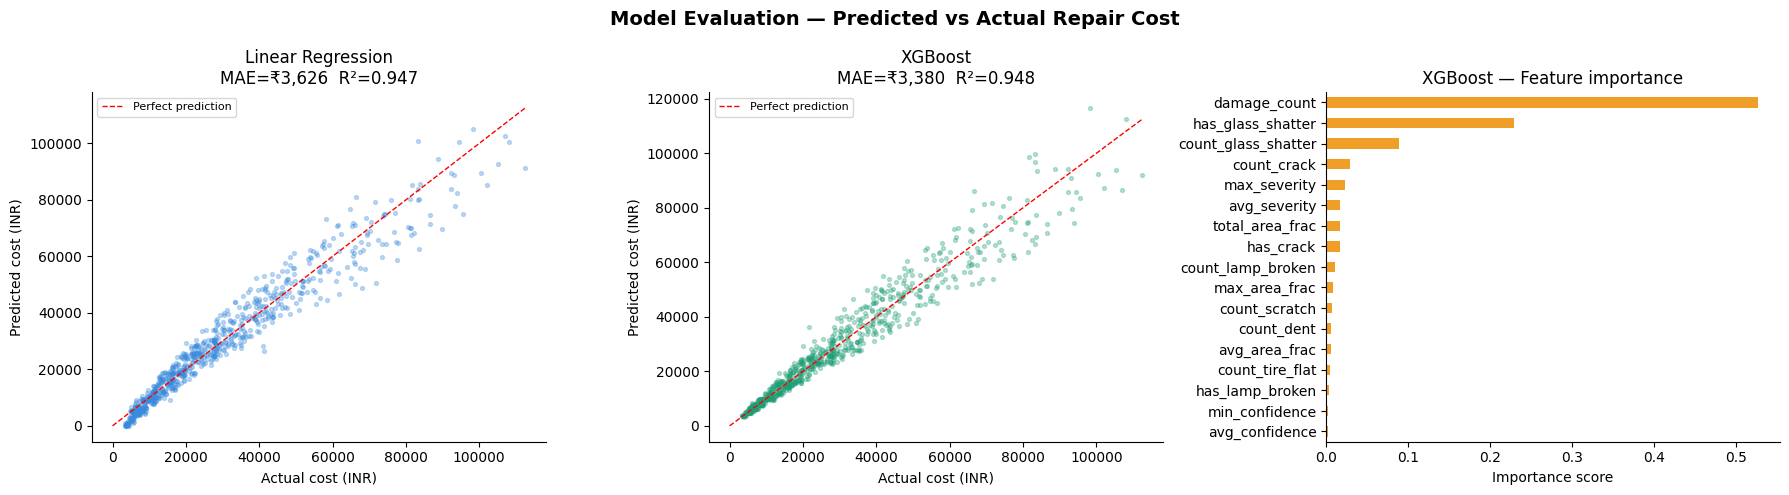

✅ Model evaluation chart saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation — Predicted vs Actual Repair Cost",
             fontsize=14, fontweight="bold")

# ── Plot 1: Linear Regression scatter ───────────────────────
ax = axes[0]
ax.scatter(lr_metrics["y_true"], lr_metrics["y_pred"],
           alpha=0.3, s=8, color="#378ADD")
max_val = max(lr_metrics["y_true"].max(), lr_metrics["y_pred"].max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect prediction")
ax.set_title(f"Linear Regression\nMAE=₹{lr_metrics['MAE']:,.0f}  R²={lr_metrics['R2']:.3f}")
ax.set_xlabel("Actual cost (INR)")
ax.set_ylabel("Predicted cost (INR)")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── Plot 2: XGBoost scatter ─────────────────────────────────
ax2 = axes[1]
ax2.scatter(xgb_metrics["y_true"], xgb_metrics["y_pred"],
            alpha=0.3, s=8, color="#1D9E75")
ax2.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect prediction")
ax2.set_title(f"XGBoost\nMAE=₹{xgb_metrics['MAE']:,.0f}  R²={xgb_metrics['R2']:.3f}")
ax2.set_xlabel("Actual cost (INR)")
ax2.set_ylabel("Predicted cost (INR)")
ax2.legend(fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)

# ── Plot 3: Feature importance (XGBoost) ────────────────────
ax3 = axes[2]
importance = pd.Series(xgb.feature_importances_, index=FEATURES)
importance.sort_values().plot(kind="barh", ax=ax3, color="#EF9F27")
ax3.set_title("XGBoost — Feature importance")
ax3.set_xlabel("Importance score")
ax3.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Model evaluation chart saved.")

---
## 💾 Cell 10 — Save Models to Disk

In [10]:
# Save XGBoost model (best performer)
xgb_path    = OUTPUT_DIR / "cost_model_xgb.pkl"
scaler_path = OUTPUT_DIR / "feature_scaler.pkl"
meta_path   = OUTPUT_DIR / "model_metadata.json"

joblib.dump(xgb,    xgb_path)
joblib.dump(scaler, scaler_path)

# Save metadata so the backend knows what features to build
metadata = {
    "feature_names": FEATURES,
    "class_names":   CLASS_NAMES,
    "model_type":    "XGBoostRegressor",
    "target":        "repair_cost_inr",
    "test_mae":      round(xgb_metrics["MAE"]),
    "test_r2":       round(xgb_metrics["R2"], 4),
    "test_mape":     round(xgb_metrics["MAPE"], 2),
}
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Models saved:")
print(f"   XGBoost model  → {xgb_path}")
print(f"   Scaler         → {scaler_path}")
print(f"   Metadata       → {meta_path}")

✅ Models saved:
   XGBoost model  → /teamspace/studios/this_studio/CarDD-outputs/phase2/cost_model_xgb.pkl
   Scaler         → /teamspace/studios/this_studio/CarDD-outputs/phase2/feature_scaler.pkl
   Metadata       → /teamspace/studios/this_studio/CarDD-outputs/phase2/model_metadata.json


---
## 🔗 Cell 11 — Build the Full Prediction Pipeline

This is the function your FastAPI backend will call directly.
It chains: **image path → YOLO → detections → cost estimate → final JSON**

In [11]:
from ultralytics.models.yolo import YOLO
import numpy as np


class CarDamagePredictor:
    """
    Full end-to-end predictor.

    Usage:
        predictor = CarDamagePredictor(
            yolo_path     = "path/to/best.pt",
            cost_model    = "path/to/cost_model_xgb.pkl",
            metadata_path = "path/to/model_metadata.json",
        )
        result = predictor.predict("car_image.jpg")
    """

    def __init__(self, yolo_path: str, cost_model: str, metadata_path: str):
        print("Loading YOLO model...")
        self.yolo = YOLO(yolo_path)

        print("Loading cost model...")
        self.cost_model = joblib.load(cost_model)

        with open(metadata_path) as f:
            self.meta = json.load(f)

        self.feature_names = self.meta["feature_names"]
        self.class_names   = self.meta["class_names"]
        print("✅ CarDamagePredictor ready.")

    def _run_yolo(self, image_path: str) -> list:
        """Run YOLO inference and convert to clean detection list."""
        results  = self.yolo(image_path, verbose=False)[0]
        img_h, img_w = results.orig_shape

        detections = []
        for box in results.boxes:
            cls_id = int(box.cls.item())
            conf   = float(box.conf.item())
            x1, y1, x2, y2 = [float(v) for v in box.xyxy[0]]

            detections.append({
                "class":      self.class_names[cls_id],
                "class_id":   cls_id,
                "confidence": round(conf, 3),
                "bbox":       [round(x1), round(y1), round(x2), round(y2)],
            })

        return detections, img_w, img_h

    def _build_features(self, detections: list, img_w: int, img_h: int) -> np.ndarray:
        """Convert raw detections into the feature vector the cost model expects."""
        img_area = img_w * img_h

        class_counts = {cls: 0 for cls in self.class_names}
        for det in detections:
            class_counts[det["class"]] += 1

        areas = []
        for det in detections:
            x1, y1, x2, y2 = det["bbox"]
            areas.append((x2 - x1) * (y2 - y1) / img_area)

        confs = [det["confidence"] for det in detections]

        sev_map    = {"small": 1, "medium": 2, "large": 3}
        sev_scores = [sev_map[get_severity(a)] for a in areas]

        features = {
            **{f"count_{cls.replace(' ', '_')}": class_counts[cls]
               for cls in self.class_names},
            "total_area_frac":   sum(areas),
            "max_area_frac":     max(areas),
            "avg_area_frac":     sum(areas) / len(areas),
            "damage_count":      len(detections),
            "avg_confidence":    sum(confs) / len(confs),
            "min_confidence":    min(confs),
            "max_severity":      max(sev_scores),
            "avg_severity":      sum(sev_scores) / len(sev_scores),
            "has_glass_shatter": int(class_counts.get("glass shatter", 0) > 0),
            "has_crack":         int(class_counts.get("crack", 0) > 0),
            "has_lamp_broken":   int(class_counts.get("lamp broken", 0) > 0),
        }

        # Return in the exact order the model was trained on
        return np.array([[features[f] for f in self.feature_names]])

    def predict(self, image_path: str) -> dict:
        """
        Full prediction pipeline.

        Returns a dict ready to send as JSON from your API:
        {
          detections:     [...],     # YOLO boxes with class + confidence
          rule_estimate:  {...},     # rule-based cost breakdown
          ml_estimate:    int,       # XGBoost cost prediction
          final_estimate: int,       # blend of both (more robust)
          damage_count:   int,
          severity:       str,
          claim_recommended: bool,
        }
        """
        # Step 1: YOLO inference
        detections, img_w, img_h = self._run_yolo(image_path)

        if not detections:
            return {
                "detections":       [],
                "rule_estimate":    {"estimated_cost": 0},
                "ml_estimate":      0,
                "final_estimate":   0,
                "damage_count":     0,
                "severity":         "No damage detected",
                "claim_recommended": False,
            }

        # Step 2: Rule-based estimate
        rule_est = rule_based_estimate(detections, img_w, img_h)

        # Step 3: ML estimate
        feature_vec = self._build_features(detections, img_w, img_h)
        ml_cost     = max(0, float(self.cost_model.predict(feature_vec)[0]))

        # Step 4: Blend rule + ML (60% ML, 40% rule — ML is more accurate)
        final_cost = round(0.60 * ml_cost + 0.40 * rule_est["estimated_cost"])

        # Step 5: Severity and claim decision
        if final_cost < 5000:
            severity = "Minor"
            claim_recommended = False
        elif final_cost < 20000:
            severity = "Moderate"
            claim_recommended = True
        elif final_cost < 50000:
            severity = "Severe"
            claim_recommended = True
        else:
            severity = "Major"
            claim_recommended = True

        return {
            "detections":        detections,
            "rule_estimate":     rule_est,
            "ml_estimate":       round(ml_cost),
            "final_estimate":    final_cost,
            "damage_count":      len(detections),
            "severity":          severity,
            "claim_recommended": claim_recommended,
        }


print("✅ CarDamagePredictor class defined.")

✅ CarDamagePredictor class defined.


---
## 🧪 Cell 12 — Test the Full Pipeline End-to-End

In [17]:
# Load the predictor (uses your real trained YOLO model)
predictor = CarDamagePredictor(
    yolo_path     = str(MODEL_PATH),
    cost_model    = str(xgb_path),
    metadata_path = str(meta_path),
)

# Test on a real image from your dataset
TEST_IMAGE = "/teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/images/test"
test_imgs  = list(Path(TEST_IMAGE).glob("*.jpg"))

if test_imgs:
    sample_img = str(test_imgs[20])
    print(f"Running on: {sample_img}\n")

    result = predictor.predict(sample_img)

    print("═"*55)
    print("  FULL PREDICTION OUTPUT")
    print("═"*55)
    print(f"  Damages found      : {result['damage_count']}")
    print(f"  Severity           : {result['severity']}")
    print(f"  Rule-based cost    : ₹{result['rule_estimate']['estimated_cost']:,}")
    print(f"  ML model cost      : ₹{result['ml_estimate']:,}")
    print(f"  FINAL ESTIMATE     : ₹{result['final_estimate']:,}")
    print(f"  Claim recommended  : {'YES' if result['claim_recommended'] else 'NO'}")
    print("\n  Detections:")
    for d in result["detections"]:
        print(f"    {d['class']:<15} conf={d['confidence']}  bbox={d['bbox']}")

    print("\n  Cost breakdown per damage:")
    for item in result["rule_estimate"].get("breakdown", []):
        print(f"    {item['class']:<15} severity={item['severity']:<6} "
              f"₹{item['cost_min']:,} – ₹{item['cost_max']:,}")
else:
    print("⚠️  No test images found. Check your TEST_IMAGE path.")

Loading YOLO model...
Loading cost model...
✅ CarDamagePredictor ready.
Running on: /teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/images/test/002887.jpg



═══════════════════════════════════════════════════════
  FULL PREDICTION OUTPUT
═══════════════════════════════════════════════════════
  Damages found      : 1
  Severity           : Moderate
  Rule-based cost    : ₹14,218
  ML model cost      : ₹20,908
  FINAL ESTIMATE     : ₹18,232
  Claim recommended  : YES

  Detections:
    dent            conf=0.875  bbox=[301, 174, 640, 636]

  Cost breakdown per damage:
    dent            severity=large  ₹6,435 – ₹22,000


In [1]:
from pathlib import Path

TEST_IMAGE = "/teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/images/test"

# Directly point to image 000042
sample_img = str(Path(TEST_IMAGE) / "000965.jpg")

if Path(sample_img).exists():
    print(f"Running on: {sample_img}\n")

    result = predictor.predict(sample_img)

    print("═"*55)
    print("  FULL PREDICTION OUTPUT")
    print("═"*55)
    print(f"  Damages found      : {result['damage_count']}")
    print(f"  Severity           : {result['severity']}")
    print(f"  Rule-based cost    : ₹{result['rule_estimate']['estimated_cost']:,}")
    print(f"  ML model cost      : ₹{result['ml_estimate']:,}")
    print(f"  FINAL ESTIMATE     : ₹{result['final_estimate']:,}")
    print(f"  Claim recommended  : {'YES' if result['claim_recommended'] else 'NO'}")

    print("\n  Detections:")
    for d in result["detections"]:
        print(f"    {d['class']:<15} conf={d['confidence']}  bbox={d['bbox']}")

    print("\n  Cost breakdown per damage:")
    for item in result["rule_estimate"].get("breakdown", []):
        print(f"    {item['class']:<15} severity={item['severity']:<6} "
              f"₹{item['cost_min']:,} – ₹{item['cost_max']:,}")
else:
    print("⚠️ Image 000042.jpg not found. Check path.")

Running on: /teamspace/studios/this_studio/CarDD-outputs/yolo_dataset/images/test/000965.jpg



NameError: name 'predictor' is not defined

---
## 💾 Cell 13 — Export Standalone Python Files

These files are what your FastAPI backend will import directly.
Run this cell once and the files are ready.

In [18]:
EXPORT_DIR = Path("/teamspace/studios/this_studio/cardd-app/backend")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── cost_estimator.py ─────────────────────────────────────────
cost_estimator_code = '''
"""
cost_estimator.py
Rule-based car damage cost estimator.
Used as Layer 1 in the CarDD insurance pipeline.
"""

BASE_COST_INR = {
    "dent":          (3000,  10000),
    "scratch":       (1500,   6000),
    "crack":         (5000,  15000),
    "glass shatter": (8000,  25000),
    "tire flat":     (2000,   8000),
    "lamp broken":   (3500,  12000),
}

SEVERITY_MULTIPLIER = {"small": 1.0, "medium": 1.5, "large": 2.2}


def get_severity(bbox_area_fraction: float) -> str:
    if bbox_area_fraction < 0.05:
        return "small"
    elif bbox_area_fraction < 0.15:
        return "medium"
    return "large"


def rule_based_estimate(detections: list, img_width: int = 640, img_height: int = 640) -> dict:
    if not detections:
        return {"total_min": 0, "total_max": 0, "estimated_cost": 0,
                "breakdown": [], "damage_count": 0, "severity_summary": "No damage detected"}

    img_area = img_width * img_height
    total_min, total_max = 0, 0
    breakdown = []

    for det in detections:
        cls  = det["class"]
        conf = det["confidence"]
        x1, y1, x2, y2 = det["bbox"]
        area_frac  = (x2 - x1) * (y2 - y1) / img_area
        severity   = get_severity(area_frac)
        multiplier = SEVERITY_MULTIPLIER[severity]
        base_min, base_max = BASE_COST_INR.get(cls, (2000, 8000))
        item_min = base_min * multiplier * (0.8 + conf * 0.2)
        item_max = base_max * multiplier
        total_min += item_min
        total_max += item_max
        breakdown.append({"class": cls, "confidence": round(conf, 3),
                          "severity": severity, "area_pct": round(area_frac * 100, 1),
                          "cost_min": round(item_min), "cost_max": round(item_max)})

    count = len(detections)
    if count > 1:
        penalty = 1 + (count - 1) * 0.10
        total_min *= penalty
        total_max *= penalty

    estimated_cost = round((total_min + total_max) / 2)
    if estimated_cost < 10000:    summary = "Minor damage"
    elif estimated_cost < 30000:  summary = "Moderate damage"
    elif estimated_cost < 60000:  summary = "Severe damage"
    else:                          summary = "Major damage"

    return {"total_min": round(total_min), "total_max": round(total_max),
            "estimated_cost": estimated_cost, "breakdown": breakdown,
            "damage_count": count, "severity_summary": summary}
'''

# ── predictor.py ──────────────────────────────────────────────
predictor_code = '''
"""
predictor.py
Full end-to-end CarDD prediction pipeline.
Import this in your FastAPI backend.
"""

import json
import numpy as np
import joblib
from pathlib import Path
from ultralytics import YOLO
from cost_estimator import rule_based_estimate, get_severity


class CarDamagePredictor:

    def __init__(self, yolo_path: str, cost_model_path: str, metadata_path: str):
        self.yolo       = YOLO(yolo_path)
        self.cost_model = joblib.load(cost_model_path)
        with open(metadata_path) as f:
            self.meta = json.load(f)
        self.feature_names = self.meta["feature_names"]
        self.class_names   = self.meta["class_names"]

    def _run_yolo(self, image_path: str):
        results = self.yolo(image_path, verbose=False)[0]
        img_h, img_w = results.orig_shape
        detections = []
        for box in results.boxes:
            cls_id = int(box.cls.item())
            conf   = float(box.conf.item())
            x1, y1, x2, y2 = [float(v) for v in box.xyxy[0]]
            detections.append({"class": self.class_names[cls_id], "class_id": cls_id,
                                "confidence": round(conf, 3),
                                "bbox": [round(x1), round(y1), round(x2), round(y2)]})
        return detections, img_w, img_h

    def _build_features(self, detections, img_w, img_h):
        img_area     = img_w * img_h
        class_counts = {cls: 0 for cls in self.class_names}
        for det in detections:
            class_counts[det["class"]] += 1
        areas = [(d["bbox"][2]-d["bbox"][0])*(d["bbox"][3]-d["bbox"][1])/img_area
                 for d in detections]
        confs      = [d["confidence"] for d in detections]
        sev_map    = {"small": 1, "medium": 2, "large": 3}
        sev_scores = [sev_map[get_severity(a)] for a in areas]
        features   = {
            **{f"count_{c.replace(\' \', \'_\')}": class_counts[c] for c in self.class_names},
            "total_area_frac":    sum(areas),
            "max_area_frac":      max(areas),
            "avg_area_frac":      sum(areas)/len(areas),
            "damage_count":       len(detections),
            "avg_confidence":     sum(confs)/len(confs),
            "min_confidence":     min(confs),
            "max_severity":       max(sev_scores),
            "avg_severity":       sum(sev_scores)/len(sev_scores),
            "has_glass_shatter":  int(class_counts.get("glass shatter", 0) > 0),
            "has_crack":          int(class_counts.get("crack", 0) > 0),
            "has_lamp_broken":    int(class_counts.get("lamp broken", 0) > 0),
        }
        return np.array([[features[f] for f in self.feature_names]])

    def predict(self, image_path: str) -> dict:
        detections, img_w, img_h = self._run_yolo(image_path)
        if not detections:
            return {"detections": [], "rule_estimate": {"estimated_cost": 0},
                    "ml_estimate": 0, "final_estimate": 0, "damage_count": 0,
                    "severity": "No damage detected", "claim_recommended": False}

        rule_est    = rule_based_estimate(detections, img_w, img_h)
        feature_vec = self._build_features(detections, img_w, img_h)
        ml_cost     = max(0, float(self.cost_model.predict(feature_vec)[0]))
        final_cost  = round(0.60 * ml_cost + 0.40 * rule_est["estimated_cost"])

        if final_cost < 5000:    severity, claim = "Minor",    False
        elif final_cost < 20000: severity, claim = "Moderate", True
        elif final_cost < 50000: severity, claim = "Severe",   True
        else:                     severity, claim = "Major",    True

        return {"detections": detections, "rule_estimate": rule_est,
                "ml_estimate": round(ml_cost), "final_estimate": final_cost,
                "damage_count": len(detections), "severity": severity,
                "claim_recommended": claim}
'''

(EXPORT_DIR / "cost_estimator.py").write_text(cost_estimator_code.strip())
(EXPORT_DIR / "predictor.py").write_text(predictor_code.strip())

# Copy model files to backend folder
import shutil
shutil.copy(xgb_path,    EXPORT_DIR / "cost_model_xgb.pkl")
shutil.copy(scaler_path, EXPORT_DIR / "feature_scaler.pkl")
shutil.copy(meta_path,   EXPORT_DIR / "model_metadata.json")

print("✅ All backend files exported to:")
print(f"   {EXPORT_DIR}")
print("\n   Files ready for Phase 3 (FastAPI):")
for f in sorted(EXPORT_DIR.iterdir()):
    print(f"     {f.name}")

✅ All backend files exported to:
   /teamspace/studios/this_studio/cardd-app/backend

   Files ready for Phase 3 (FastAPI):
     cost_estimator.py
     cost_model_xgb.pkl
     feature_scaler.pkl
     model_metadata.json
     predictor.py


---
## 🏁 Cell 14 — Phase 2 Summary

In [19]:
print("═"*60)
print("  PHASE 2 COMPLETE — COST ESTIMATION ENGINE")
print("═"*60)

print(f"""
  What was built:
  ─────────────────────────────────────────────
  Layer 1  Rule-based estimator
           Uses damage type + bbox area + confidence
           No model needed, always works, fully transparent

  Layer 2  XGBoost ML regressor
           Trained on 5000 synthetic scenarios
           MAE  : ₹{round(xgb_metrics['MAE']):,}
           R²   : {xgb_metrics['R2']:.4f}
           MAPE : {xgb_metrics['MAPE']:.2f}%

  Final    60% ML + 40% Rule blend
           More robust than either alone

  Files saved to cardd-app/backend/:
    cost_estimator.py      ← rule-based logic
    predictor.py           ← full pipeline class
    cost_model_xgb.pkl     ← trained XGBoost
    model_metadata.json    ← feature names + metrics

  Next Step → Phase 3: FastAPI Backend
  Just import CarDamagePredictor from predictor.py
  and wrap it in a /predict POST endpoint.
""")

════════════════════════════════════════════════════════════
  PHASE 2 COMPLETE — COST ESTIMATION ENGINE
════════════════════════════════════════════════════════════

  What was built:
  ─────────────────────────────────────────────
  Layer 1  Rule-based estimator
           Uses damage type + bbox area + confidence
           No model needed, always works, fully transparent

  Layer 2  XGBoost ML regressor
           Trained on 5000 synthetic scenarios
           MAE  : ₹3,380
           R²   : 0.9484
           MAPE : 11.23%

  Final    60% ML + 40% Rule blend
           More robust than either alone

  Files saved to cardd-app/backend/:
    cost_estimator.py      ← rule-based logic
    predictor.py           ← full pipeline class
    cost_model_xgb.pkl     ← trained XGBoost
    model_metadata.json    ← feature names + metrics

  Next Step → Phase 3: FastAPI Backend
  Just import CarDamagePredictor from predictor.py
  and wrap it in a /predict POST endpoint.

